# Framework Tests

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## Creating and Manipulating Tensor objects

In [2]:
from engine import Tensor

In [3]:
print('TENSOR OBJECT ATTRIBUTES:')
x = Tensor(np.arange(16).reshape(4, 4))
print('x =', x)
print('x.data:', x.data)
print('x.requires_grad:', x.requires_grad)
print('x.shape:', x.shape)
print('len(x):', len(x))
print('element [0,0]:', x[0, 0])
print('x.grad:', x.grad)

TENSOR OBJECT ATTRIBUTES:
x = Tensor(data=[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]])
x.data: [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]
x.requires_grad: False
x.shape: (4, 4)
len(x): 4
element [0,0]: Tensor(data=0.0)
x.grad: [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [4]:
print('\nTENSOR ARITHMETICS (SCALARS):')
a = Tensor([3])
b = 2
print('a:', a, 'b:', b)
print('a+b:', a+b)
print('b+a:', b+a)
print('a*b:', a*b)
print('b*a:', b*a)
print('a-b:', a-b)
print('b-a:', b-a)
print('a**b:', a**b)
print('a/b:', a/b)
print('log(a):', a.log())
print('exp(a):', a.exp())


TENSOR ARITHMETICS (SCALARS):
a: Tensor(data=[3.]) b: 2
a+b: Tensor(data=[5.])
b+a: Tensor(data=[5.])
a*b: Tensor(data=[6.])
b*a: Tensor(data=[6.])
a-b: Tensor(data=[1.])
b-a: Tensor(data=[-1.])
a**b: Tensor(data=[9.])
a/b: Tensor(data=[1.5])
log(a): Tensor(data=[1.0986123])
exp(a): Tensor(data=[20.085537])


In [5]:
print('TENSOR ARITHMETICS (MATRICES):')
a = Tensor([[1, 2, 3], 
            [4, 5, 6], 
            [7, 8, 9]])
b = Tensor([[1], [1], [1]])
print('a.shape:', a.shape)
print('b.shape:', b.shape)
print('a:', a, 'b:', b)
print('a+b:', a+b)
print('b+a:', b+a)
print('a*b:', a*b)
print('b*a:', b*a)
print('a-b:', a-b)
print('b-a:', b-a)
print('a/b:', a/b)
print('log(a):', a.log())
print('mean(a):', a.mean())
print('max(a):', a.max())
print('sum(a):', a.sum())
print('a @ b:', a @ b)
print('relu(a):', a.relu())
print('tanh(a):', a.tanh())

TENSOR ARITHMETICS (MATRICES):
a.shape: (3, 3)
b.shape: (3, 1)
a: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]) b: Tensor(data=[[1.]
 [1.]
 [1.]])
a+b: Tensor(data=[[ 2.  3.  4.]
 [ 5.  6.  7.]
 [ 8.  9. 10.]])
b+a: Tensor(data=[[ 2.  3.  4.]
 [ 5.  6.  7.]
 [ 8.  9. 10.]])
a*b: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
b*a: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
a-b: Tensor(data=[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]])
b-a: Tensor(data=[[ 0. -1. -2.]
 [-3. -4. -5.]
 [-6. -7. -8.]])
a/b: Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
log(a): Tensor(data=[[0.        0.6931472 1.0986123]
 [1.3862944 1.609438  1.7917595]
 [1.9459102 2.0794415 2.1972246]])
mean(a): Tensor(data=5.0)
max(a): Tensor(data=9.0)
sum(a): Tensor(data=45.0)
a @ b: Tensor(data=[[ 6.]
 [15.]
 [24.]])
relu(a): Tensor(data=[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]])
tanh(a): Tensor(data=[[0.7615942  0.9640276  0.9950548 ]
 [0.9993293  0.9999092  0.9999877 ]
 [0.99999833 0.99999976 1.        ]])


## Testing API elements

In [6]:
from layers import Linear, BatchNorm1d, Dropout
from activations import ReLU, Tanh
from models import Sequential

### 1. Linear

In [7]:
linear = Linear(4, 8) # arbitrary values
linear

Linear(in_features=4, out_features=8, bias=True)

In [8]:
# Checking the attributes
linear.w.shape, linear.b.shape

((4, 8), (8,))

In [9]:
linear.w[0]

Tensor(data=[ 0.17126967 -0.07268284  0.95678955 -0.44434574 -0.82235116  0.921559
 -0.35919788  0.6962902 ], requires_grad=True)

In [10]:
linear.parameters()

[Tensor(data=[[ 0.17126967 -0.07268284  0.95678955 -0.44434574 -0.82235116  0.921559
   -0.35919788  0.6962902 ]
  [-0.38198364 -0.00275489  0.22911382  0.30315715  0.9436486   1.007771
   -0.5786387   0.22228654]
  [ 0.3421142   1.1155564  -0.7102884   1.5419788  -0.6278898  -0.18240516
    0.78081733 -0.6755667 ]
  [-0.54956883  0.6412661  -0.12220483  1.3211061   0.02627088 -0.1211533
   -0.5728481   0.3267651 ]], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True)]

In [11]:
# __call__ test
x = Tensor(np.random.randn(4).reshape(1, 4))
y = linear(x)
y

Tensor(data=[[-0.18179438  1.1346984  -0.22025092  1.8371341  -0.3604577   0.35187298
  -0.10748619  0.01277256]], requires_grad=True)

### 2. BatchNorm1d

In [12]:
bn = BatchNorm1d(8)
bn

BatchNorm1d(features=8)

In [13]:
bn.parameters()

[Tensor(data=[1. 1. 1. 1. 1. 1. 1. 1.], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True)]

In [14]:
bn = BatchNorm1d(8)
bn.train()
y = bn(y)
y

Tensor(data=[[0. 0. 0. 0. 0. 0. 0. 0.]], requires_grad=True)

### 3. Dropout

In [15]:
dropout = Dropout(keep_prob=0.5)
dropout

Dropout(keep_prob=0.5)

In [16]:
x = Tensor(np.random.randn(9).reshape(3, 3))
x

Tensor(data=[[-1.0045061   0.3342166   0.78977805]
 [ 0.5685949   1.0769541  -0.6893183 ]
 [ 0.67093176 -0.14983663 -1.0462089 ]])

In [17]:
dropout.train()
y = dropout(x)
y

Tensor(data=[[-2.0090122  0.         1.5795561]
 [ 1.1371897  0.        -0.       ]
 [ 1.3418635 -0.        -0.       ]])

### 4. Relu & Tanh

In [18]:
x = Tensor(np.arange(-10, 10))
x

Tensor(data=[-10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.])

In [19]:
out = ReLU()(x)
out

Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7. 8. 9.])

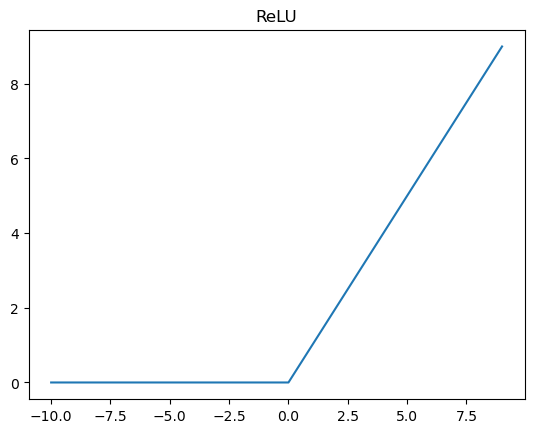

In [20]:
plt.plot(x.data, out.data)
plt.title('ReLU');

In [21]:
out = Tanh()(x)
out

Tensor(data=[-1.         -1.         -0.99999976 -0.99999833 -0.99998766 -0.99990916
 -0.9993293  -0.9950548  -0.9640276  -0.7615941   0.          0.7615942
  0.9640276   0.9950548   0.9993293   0.9999092   0.9999877   0.99999833
  0.99999976  1.        ])

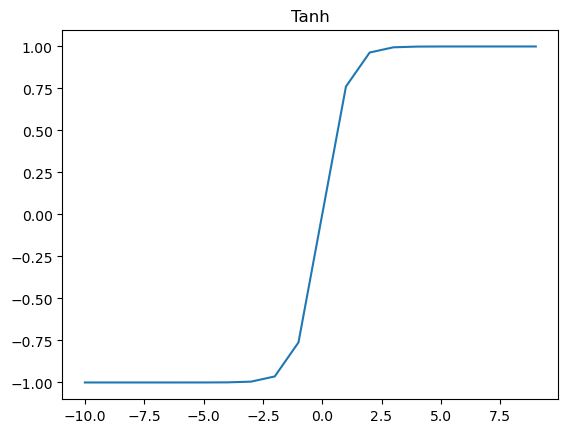

In [22]:
plt.plot(x.data, out.data)
plt.title('Tanh');

### 5. Sequential

In [23]:
model = Sequential(
    Linear(3, 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8)
)
model

Sequential((Linear(in_features=3, out_features=16, bias=True), BatchNorm1d(features=16), ReLU(), Dropout(keep_prob=0.9), Linear(in_features=16, out_features=8, bias=True)))

In [24]:
x = Tensor(np.random.randn(9).reshape(3, 3))
x

Tensor(data=[[ 2.0965042  -1.2684771   0.4282068 ]
 [-0.99913114 -2.007574   -0.04629959]
 [ 0.77742314 -1.9300091   0.37403998]])

In [25]:
model(x)

Tensor(data=[[-1.1082293  -2.143402   -2.707561   -0.10227736 -2.2029116   2.1476445
   3.7294388  -0.9758914 ]
 [-0.95104617  1.8340834  -0.23915169  0.66063964  0.75393796  1.1906613
   0.69169706 -0.32281587]
 [-0.8881704  -0.7001269  -1.6750783  -0.3912551  -0.8399437   2.5793235
   1.6430988  -0.7672123 ]], requires_grad=True)

In [26]:
model.parameters()

[Tensor(data=[[-0.84406185 -1.4378442   1.2982593  -0.05026345  2.1673079   0.27318546
   -1.2353473  -0.9918842   1.4623389  -0.4648014  -1.1096491   0.4601788
    0.14825799 -1.6210717  -1.0203259  -0.562624  ]
  [ 0.21650688 -0.6601457  -0.84220755  0.6896636   0.19173253 -0.5624927
   -1.023954    0.86738735 -0.70251673  1.4980705  -0.8683184  -0.06117108
    0.52912843  1.6204288   0.26485562 -0.2680834 ]
  [-0.8617739   1.6519291  -1.0209073   0.9721992  -0.19361913  0.4370333
   -0.12490536  0.6719938  -0.5154413   0.8664288   0.8863179  -1.3545088
    1.3526568   1.0165186   0.5694213   0.25465384]], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True),
 Tensor(data=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.], requires_grad=True),
 Tensor(data=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], requires_grad=True),
 Tensor(data=[[-3.95865768e-01  2.94030130e-01  1.11592636e-01 -8.83278176e-02
    6.69694901e-01 -7.7773791

## Training MLP

In [27]:
from optimizers import Adam
from functions import cross_entropy

In [28]:
# train data
x_train = Tensor([
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
])

# train targets
y_train = np.array([1, 0, 0, 1], dtype=np.int32)

# test data
x_test = Tensor([
    [2.5,  2.5, -0.8],   
    [3.2, -0.7,  0.3],  
    [0.7,  1.2,  0.8],  
    [1.2,  0.8, -0.9], 
    [2.2,  3.1, -1.2],
    [2.8, -1.2,  0.7], 
])

# test targets
y_test = np.array([1, 0, 0, 1, 1, 0], dtype=np.int32)


model = Sequential(
    Linear(x_train.shape[1], 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8), BatchNorm1d(8), ReLU(),
    Linear(8, 2)
)

optimizer = Adam(parameters=model.parameters(), lr=0.001)

epochs = 1000
loop = tqdm(range(epochs), total=epochs, desc='Training')
train_losses = []
test_losses = []

for epoch in loop:
    # ------- TRAINING --------
    model.train()
    
    # Forward pass
    y_pred_logits = model(x_train)

    # Loss
    loss = cross_entropy(y_pred_logits, y_train)
    train_losses.append(loss.data)

    # Zero grad
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update
    optimizer.update()

    # ------ EVALUATING ------
    model.evaluate()

    # Forward pass
    y_pred_logits = model(x_test)

    # Loss
    loss = cross_entropy(y_pred_logits, y_test)
    test_losses.append(loss.data)
    
    # Track test loss
    loop.set_postfix(test_loss=f'{loss.data}')

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

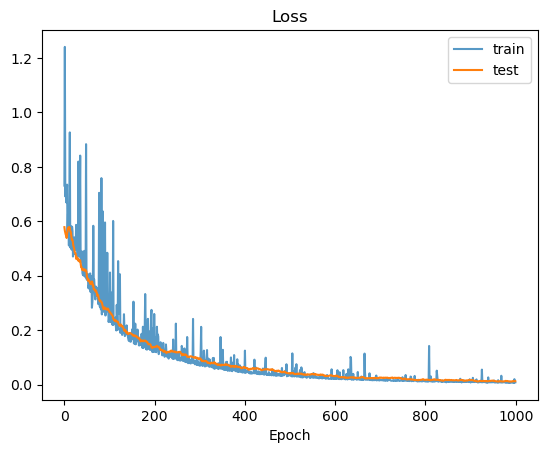

In [29]:
plt.plot(train_losses, alpha=0.75, label='train')
plt.plot(test_losses, label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend();

### Training using `.run_autotraining()`

In [30]:
# SETUP

x_train = Tensor([
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
])

y_train = np.array([1, 0, 0, 1], dtype=np.int32)

x_test = Tensor([
    [2.5,  2.5, -0.8],   
    [3.2, -0.7,  0.3],  
    [0.7,  1.2,  0.8],  
    [1.2,  0.8, -0.9], 
    [2.2,  3.1, -1.2],
    [2.8, -1.2,  0.7], 
])

y_test = np.array([1, 0, 0, 1, 1, 0], dtype=np.int32)


model = Sequential(
    Linear(x_train.shape[1], 16), BatchNorm1d(16), ReLU(),
    Dropout(keep_prob=0.9),
    Linear(16, 8), BatchNorm1d(8), ReLU(),
    Linear(8, 2)
)

optimizer = Adam(parameters=model.parameters(), lr=0.001)
epochs = 1000

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

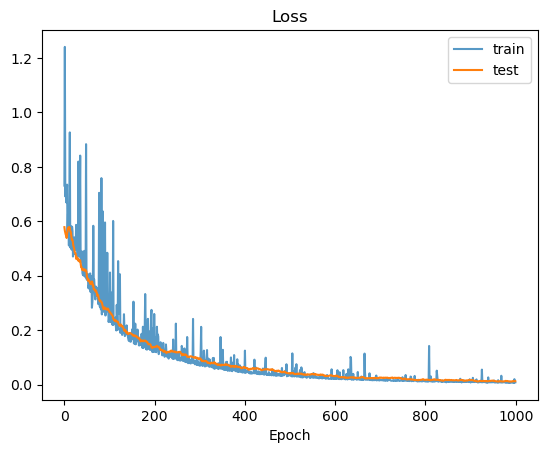

In [31]:
# TRAIN & PLOT
model.run_autotraining(epochs, optimizer, cross_entropy, x_train, y_train, x_test, y_test)

plt.plot(train_losses, alpha=0.75, label='train')
plt.plot(test_losses, label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend();